## 4.1: Using data science packages in Jupyter notebooks.

In [ ]:
#pip install numpy pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 27.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 36.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 20.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 32.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 35.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/15 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
# Import packages

## Most coding styles require package imports at the top of the notebook.
## This style prevents running much of a notebook to find a package needs to be installed.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [4]:
# Use pandas to load the hawks dataset
hawks = pd.read_csv('hawks.csv')
hawks.head()

,Species,Age,Wing,Weight,Culmen,Hallux,Tail
0,RT,I,385.0,920,25.7,30.1,219
1,RT,I,381.0,990,26.7,31.3,235
2,CH,I,265.0,470,18.7,23.5,220
3,SS,I,205.0,170,12.5,14.3,157
4,RT,I,412.0,1090,28.5,32.2,230


This dataset includes data about hawks at a nature preserve in Iowa.
 * Species - CH:Cooper's Hawk, SS:Sharp-shinned Hawk, RT:Redtail Hawk
 * Age - A:Adult, I:Immature
 * Wing - length of the primary wing feather in mm
 * Weight - Body weight in g
 * Culmen - Length along the top of the bill from tip to face in mm
 * Hallux - Length in mm of the killing talon
 * Tail - Aggregate measurement related to the length of the tail in mm

In [5]:
# Calculate summary statistics using dataframe.describe() from pandas
hawks.describe(include='all')

,Species,Age,Wing,Weight,Culmen,Hallux,Tail
count,891,891,891.000000,891.000000,891.000000,891.000000,891.000000
unique,3,2,NaN,NaN,NaN,NaN,NaN
top,RT,I,NaN,NaN,NaN,NaN,NaN
freq,567,672,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,315.947475,771.615039,21.808923,26.413244,198.893378
std,NaN,NaN,95.316699,462.936901,7.293190,17.825541,36.826634
min,NaN,NaN,37.200000,56.000000,8.600000,9.500000,119.000000
25%,NaN,NaN,202.000000,185.000000,12.800000,15.100000,160.000000
50%,NaN,NaN,370.000000,970.000000,25.500000,29.400000,214.000000
75%,NaN,NaN,390.000000,1120.000000,27.350000,31.400000,225.000000


<Axes: xlabel='Wing', ylabel='Weight'>

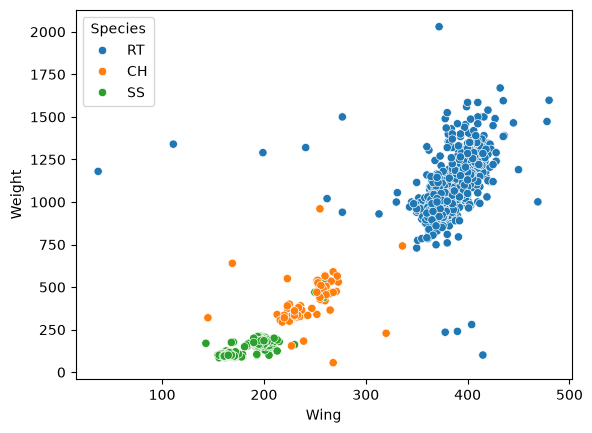

In [6]:
# Visualize the relationship between wing span and weight using seaborn
sns.scatterplot(data=hawks, x='Wing', y='Weight', hue='Species')

In [6]:
# Calculate the mean for each feature according to each species.

## pandas makes calculating statistics of groups easy with the groupby function.
hawks.groupby('Species').mean(numeric_only=True)



,Wing,Weight,Culmen,Hallux,Tail
Species,,,,,
CH,244.144928,419.623188,17.563768,22.684058,200.956522
RT,383.629982,1094.841270,26.974956,32.014198,222.125220
SS,184.882353,148.156863,11.470784,14.968431,146.678431


In [7]:
# Predict weight based on wing length
X = hawks[['Wing']]
y = hawks[['Weight']]

# Create a training/testing split using scikit-learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [8]:
# Use a linear regression model from scikit-learn
linearModel = LinearRegression()
linearModel.fit(X_train, y_train)  # Fit the model on the training set

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[4.65]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Wing']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-699.72]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
# Make predictions for the test set using scikit-learn
y_pred = linearModel.predict(X_test)
y_pred[:5]

array([[1144.68590644],
       [1121.45661033],
       [1009.95598899],
       [ 271.26437266],
       [  34.32555233]])